In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import chi2
import uproot

from daq import sum_daq_muon, sum_daq_time
from plot_style import set_plot_style, set_plot_colorbar_style
from timestamp import TimeStamp

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    # small preamble to support \text and amsmath usage
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 100,
})

In [2]:
filename = "~/Documents/test/analysis_ibd_summary_test/ReProd25C/RUN.9789-9899.output.reprod25c.root"
with uproot.open(filename) as f:
    tree = f["CosmoRateWithNeutronAnalysis__OMILREC_JVtx"]
    posx_p = tree["posx_p"].array(library="np")
    posy_p = tree["posy_p"].array(library="np")
    posz_p = tree["posz_p"].array(library="np")
    e_p = tree["e_p"].array(library="np")
    totq_p = tree["totq_p"].array(library="np")
    ts_p = np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree["sec_p"].array(library="np"), tree["nsec_p"].array(library="np"))])
    
    posx_d = tree["posx_d"].array(library="np")
    posy_d = tree["posy_d"].array(library="np")
    posz_d = tree["posz_d"].array(library="np")
    e_d = tree["e_d"].array(library="np")
    totq_d = tree["totq_d"].array(library="np")
    ts_d = np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree["sec_d"].array(library="np"), tree["nsec_d"].array(library="np"))])

    dlat_p = tree["dlat_p"]
    dlat_d = tree["dlat_d"]
    dt_mu2p = np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree["dt_mu2p_sec"].array(library="np"), tree["dt_mu2p_nsec"].array(library="np"))])
    dt_mu2d = np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree["dt_mu2d_sec"].array(library="np"), tree["dt_mu2d_nsec"].array(library="np"))])

    posx_n = tree["posx_n"].array(library="np")
    posy_n = tree["posy_n"].array(library="np")
    posz_n = tree["posz_n"].array(library="np")
    e_n = tree["e_n"].array(library="np")
    totq_n = tree["totq_n"].array(library="np")
    ts_n = np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree["sec_n"].array(library="np"), tree["nsec_n"].array(library="np"))])

daq_days = sum_daq_time(filename)

/tmp/ipykernel_542162/1915302362.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


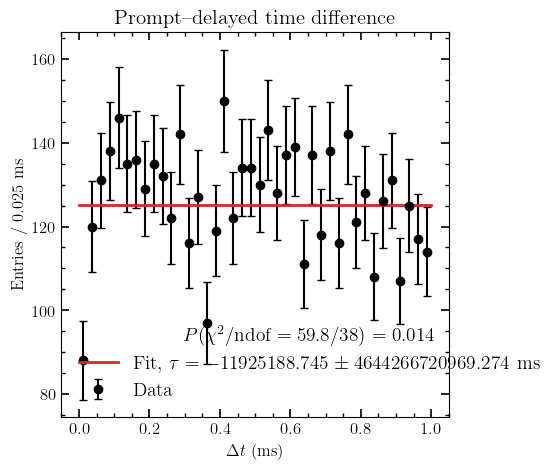

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dt_ms = np.array([dt_mu2p[k].to_sec() for k in range(len(dt_mu2p)) if e_n[k] == 0.0])

bin_min = 0.0
bin_max = 1.0
bin_width = 0.025
bin_num = (bin_max - bin_min) / bin_width
bins = np.linspace(bin_min, bin_max, int(bin_num) + 1)
bin_width = bins[1] - bins[0]

counts, edges = np.histogram(dt_ms, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

errors = np.sqrt(counts)
errors[errors == 0] = 1.0

def expo(t, A, tau):
    return A * np.exp(-t / tau)

popt, pcov = curve_fit(expo, centers, counts, sigma=errors, absolute_sigma=True)
A_fit, tau_fit = popt
A_err, tau_err = np.sqrt(np.diag(pcov))

model = expo(centers, *popt)
chi2_val = np.sum(((counts - model) / errors) ** 2)
ndof = len(counts) - len(popt)
p_value = chi2.sf(chi2_val, ndof)

ax.errorbar(
    centers, counts, yerr=errors,
    fmt='o', color="black", markersize=6, capsize=3, label='Data'
)

t_fit = np.linspace(bin_min, bin_max, 400)
ax.plot(t_fit, expo(t_fit, *popt), color="tab:red", linewidth=2,
        label=fr"Fit, $\tau = {tau_fit:.3f} \pm {tau_err:.3f}$ ms"
)

ax.set_xlabel(r"$\Delta t$ (ms)", fontsize=12)
ax.set_ylabel(fr"Entries / {bin_width:.3f} ms", fontsize=12)
ax.set_title(r"Prompt–delayed time difference", fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=16)

ax.legend(
    title=fr"$P(\chi^2 / \mathrm{{ndof}} = {chi2_val:.1f} / {ndof}) = {p_value:.3f}$",
    fontsize=14,
    title_fontsize=14,
    frameon=False
)

set_plot_style(ax)
fig.show()